# Package

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# a) normal()

In [65]:
rng = np.random.default_rng(1)
X = rng.normal(size=100)
print(X[:5])

[ 0.34558419  0.82161814  0.33043708 -1.30315723  0.90535587]


# b) Create eps

In [85]:
eps = rng.normal(loc = 0, scale = 0.25, size=100)
eps[:5]

array([-0.14819363, -0.03945918, -0.12032007, -0.17536982,  0.03454841])

# c) Create Y = -1 + 0.5X + eps

In [86]:
Y = -1 + 0.5 * X + eps

In [87]:
print("La longueur du vecteur Y est:", Y.shape)

La longueur du vecteur Y est: (100,)


B0 = -1 et B1 = 0.5

# d) Scatterplot X and Y

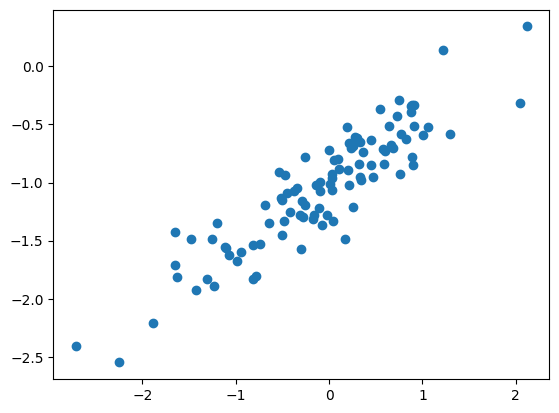

In [88]:
plt.scatter(X, Y)
plt.show()

Une régression linéaire peut vraiment s'ajuster pour capter la relation entre Y et X.

# e) Fitting least squares

In [90]:
X_const = sm.add_constant(X)
model_1 = sm.OLS(Y, X_const).fit()
print(model_1.params)

[-1.00228973  0.5367486 ]


# f) Least squares line

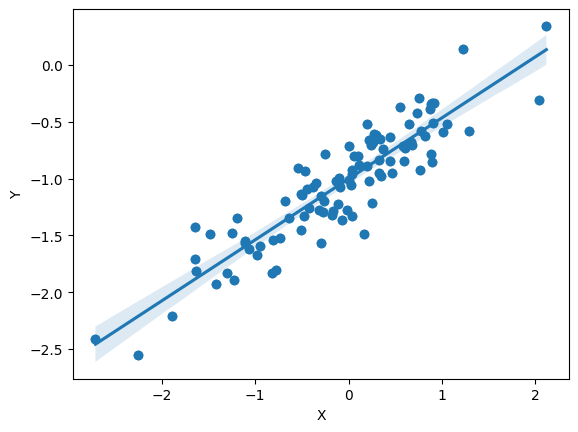

In [91]:
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
sns.regplot(x = X, y = Y)
plt.show()
# Je ne sais pas comment on peut créer la droite de régression ici

# g) Polynomial regression

In [92]:
X_square = np.square(X)
X_poly = np.column_stack((X, X**2))
X_poly = sm.add_constant(X_poly)
X_poly[:5]

array([[ 1.        ,  0.34558419,  0.11942843],
       [ 1.        ,  0.82161814,  0.67505637],
       [ 1.        ,  0.33043708,  0.10918866],
       [ 1.        , -1.30315723,  1.69821877],
       [ 1.        ,  0.90535587,  0.81966925]])

In [93]:

model_2 = sm.OLS(Y, X_poly).fit()
print(model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     218.1
Date:                Tue, 06 Jan 2026   Prob (F-statistic):           1.26e-36
Time:                        15:10:06   Log-Likelihood:                 11.564
No. Observations:                 100   AIC:                            -17.13
Df Residuals:                      97   BIC:                            -9.313
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9984      0.026    -38.556      0.0

# Commentaire
X² n'est pas significatif. Donc, la forme polynomial n'apporte une amélioration du modèle.

# h) Repeat a and f after modiying the data generation

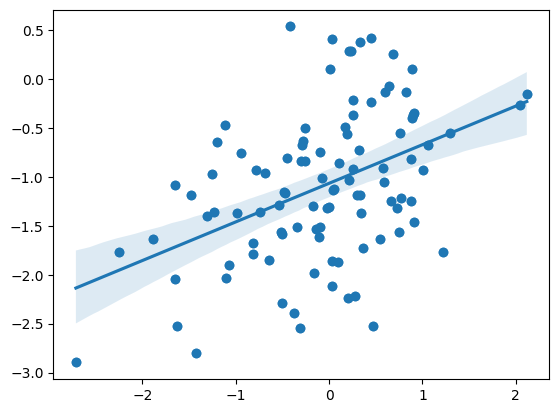

In [100]:
# Plus de noise avec une variance multiplié fois 2 et plus
eps_much_noise = rng.normal(loc = 0, scale = 0.64, size=100)
eps_much_noise[:5]

Y_much_noise = -1 + 0.5 * X + eps_much_noise

plt.scatter(X, Y_much_noise)
sns.regplot(x=X, y=Y_much_noise)
plt.show()

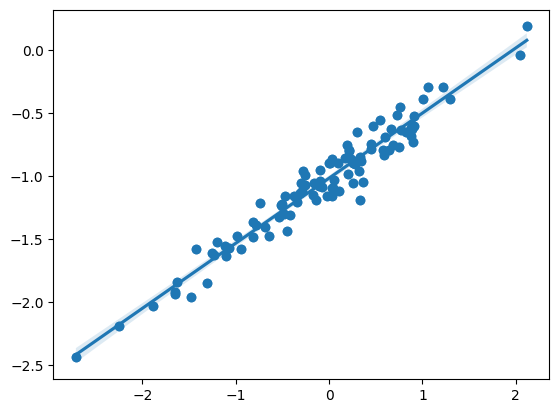

In [103]:
# Plus de noise avec une variance multiplié fois 2 et plus
eps_less_noise = rng.normal(loc = 0, scale = 0.10, size=100)
eps_less_noise[:5]

Y_less_noise = -1 + 0.5 * X + eps_less_noise

plt.scatter(X, Y_less_noise)
sns.regplot(x=X, y=Y_less_noise)
plt.show()

L'intervalle de confiance sur la droite de régression augmente par rapport à la régression ci-dessus. 

Ce qui veut dire que la confiance à la régression diminue avec plus de noise.

# (j) Interval de confiance de B0 et B1 sur les deux données

In [101]:
# model_1 sans noise
model_1.conf_int()

array([[-1.0456777 , -0.95890176],
       [ 0.48598655,  0.58751065]])

In [102]:
# model 3 : avec noise
model_3 = sm.OLS(Y_much_noise, X_const).fit()
model_3.conf_int()

array([[-1.20505451, -0.92814163],
       [ 0.23253851,  0.5565146 ]])

L'intervalle de confiance a augmenté pour le coefficient B1. Le modèle est donc moins sûr de la relation entre X et Y en moyenne.

Par rapport à B0, l'interval a diminué.